In [1]:
import pandas as pd
import os

# 1. Chargement du fichier CSV des métadonnées
metadata_path = "../data/raw/melanoma/HAM10000_metadata.csv"
df_meta = pd.read_csv(metadata_path)

# 2. Affichage des 5 premières lignes pour inspecter les colonnes
print("Aperçu des métadonnées :")
display(df_meta.head())

# 3. Vérification de la répartition des types de lésions (colonne 'dx')
print("\nRépartition des classes de lésions (colonne 'dx') :")
print(df_meta['dx'].value_counts())

Aperçu des métadonnées :


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear



Répartition des classes de lésions (colonne 'dx') :
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


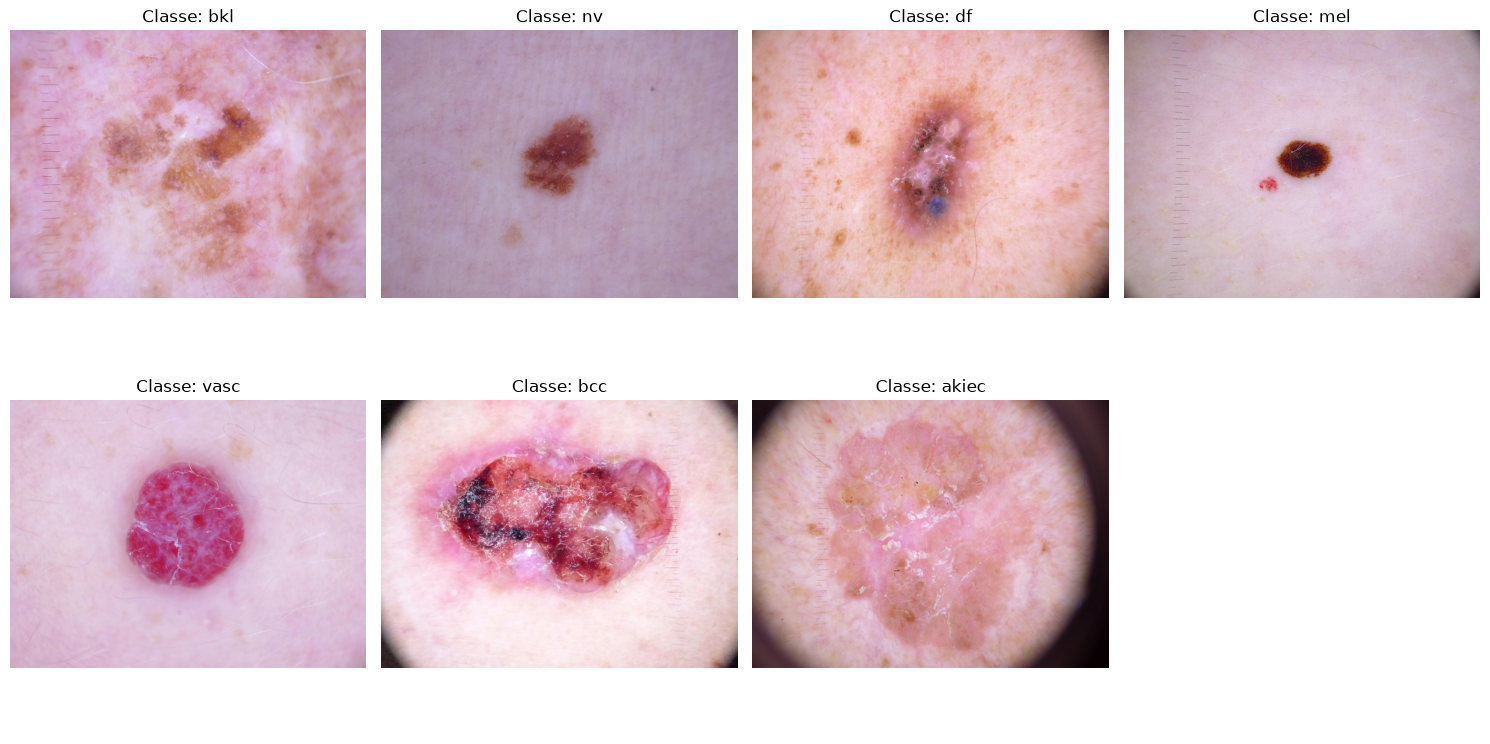

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Fusionner les deux dossiers d'images pour chercher plus facilement
image_paths = {
    os.path.splitext(img)[0]: os.path.join("../data/raw/melanoma/HAM10000_images_part_1", img) 
    for img in os.listdir("../data/raw/melanoma/HAM10000_images_part_1")
}
image_paths.update({
    os.path.splitext(img)[0]: os.path.join("../data/raw/melanoma/HAM10000_images_part_2", img) 
    for img in os.listdir("../data/raw/melanoma/HAM10000_images_part_2")
} )

# 2. Ajouter le chemin complet dans le DataFrame
df_meta['path'] = df_meta['image_id'].map(image_paths)

# 3. Afficher une image pour chaque classe principale
unique_dx = df_meta['dx'].unique()
fig, axes = plt.subplots(2, 4, figsize=(15, 8))
axes = axes.flatten()

for i, dx in enumerate(unique_dx):
    # Trouver la première image de cette classe
    sample_row = df_meta[df_meta['dx'] == dx].iloc[0]
    img_path = sample_row['path']
    
    # Charger et afficher l'image
    img = plt.imread(img_path)
    axes[i].imshow(img)
    axes[i].set_title(f"Classe: {dx}")
    axes[i].axis('off')

# Cacher le dernier subplot s'il est vide
if len(unique_dx) < len(axes):
    axes[-1].axis('off')

plt.tight_layout()
plt.show()

/tmp/ipykernel_75351/738477360.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_meta, x='dx', order=df_meta['dx'].value_counts().index, palette='viridis')


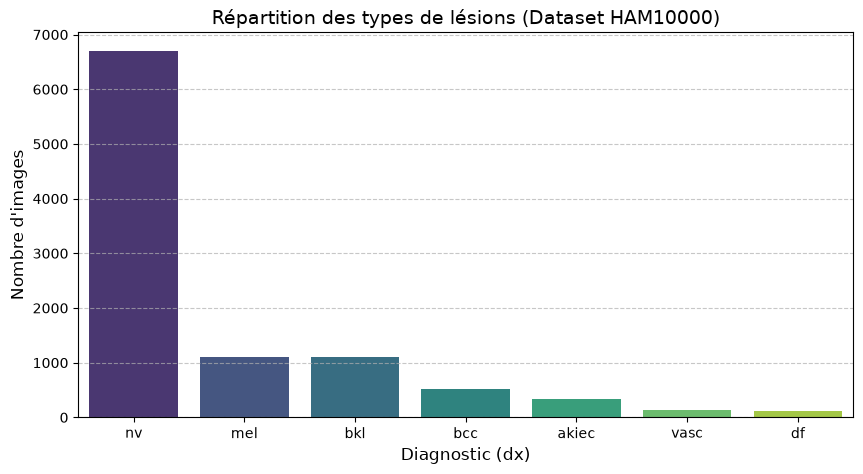

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

# Configuration du style
plt.figure(figsize=(10, 5))
sns.countplot(data=df_meta, x='dx', order=df_meta['dx'].value_counts().index, palette='viridis')

plt.title('Répartition des types de lésions (Dataset HAM10000)', fontsize=14)
plt.xlabel('Diagnostic (dx)', fontsize=12)
plt.ylabel("Nombre d'images", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()